## "Business Analytics"

**Author:** Anurag Rathore 
            Jaydeep Parmar

---

**Title:** GPU Performance and Market Insights: Driving Business Decisions with Analytics

**Sources:** Dataset sourced from Kaggle, March 15, 2023. https://www.kaggle.com/datasets/alanjo/gpu-benchmarks

---

## **Situation**
You are a data analyst working in NVIDIA’s analytics division. NVIDIA is recognized as an industry leader in GPU manufacturing, but it faces ongoing challenges in maintaining its competitive edge. Specifically, there is growing competition in three key areas:
1. **Price-to-Performance**: Competitors are delivering GPUs with better price-to-performance ratios for budget-conscious customers.
2. **Energy Efficiency**: High `TDP` (Thermal Design Power) of certain NVIDIA GPUs has raised concerns for data centers and eco-conscious users.
3. **Market Segmentation**: With a wide array of GPUs targeting gaming, workstations, and AI workloads, NVIDIA must refine its product offerings and tailor strategies to better meet customer needs.

The analysis aims to tackle these challenges by deriving actionable insights from a curated dataset of GPU benchmarks.

---

## **1. Business Problems**

1. **Price-to-Performance Optimization**  
   NVIDIA needs to identify which factors most significantly influence the price-to-performance ratio (`gpuValue`) to optimize product pricing and maximize customer value.

2. **Energy Efficiency Improvements**  
   NVIDIA seeks to improve the energy efficiency of its GPUs by analyzing `powerPerformance` (performance per watt).  

3. **Market Segmentation by Use Case**  
   NVIDIA wants to segment its GPUs into meaningful market clusters (e.g., gaming, workstation) to identify gaps and refine marketing strategies.

---

## **2. Analytics Problems**
### Addressing each business problem:
1. **Price-to-Performance Optimization**:  
   - Predict `gpuValue` using features like `price`, `G3DMark`, `TDP`, and `powerPerformance`.  
   - Build regression models and analyze feature importance.

2. **Energy Efficiency Improvements**:  
   - Predict `powerPerformance` and identify drivers like `TDP` and `G3DMark`.  
   - Use regression models to prioritize actionable areas for efficiency improvements.

3. **Market Segmentation**:  
   - Apply clustering techniques (K-Means) to group GPUs into clear segments.  
   - Identify distinct market clusters based on price, performance, and energy metrics.

---

## **3. Allocation**

We have formulated business and analytics problems. To solve these, we identified a dataset on Kaggle that is well-curated and provides initial insights into GPU performance and market segmentation. However, the dataset is not extensive, so simple local infrastructure or free online computational resources are sufficient for this analysis.

If this were to be conducted in a business context, ensure proper handling of data security and compliance with NVIDIA’s data governance policies. Always verify the source and usage permissions of any external datasets.


---

## **4. Analytics**

### Problem 1: Price-to-Performance Optimization
- **Method:** Regression model (Random Forest) to predict `gpuValue`.  
- **Results:** Insights into which factors drive customer value, such as `G3DMark` or `price`.

### Problem 2: Energy Efficiency Improvements
- **Method:** Regression model to analyze energy efficiency (`powerPerformance`).  
- **Results:** Clear understanding of how `TDP` and `G3DMark` influence efficiency for data center and portable GPUs.

### Problem 3: Market Segmentation
- **Method:** K-Means clustering to identify distinct GPU categories.  
- **Results:** Group GPUs into categories like gaming, workstation, and general-purpose GPUs.

---


In [85]:
### Import Libraries
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import RobustScaler, LabelEncoder
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.cluster import KMeans
from sklearn.impute import KNNImputer
from sklearn.metrics import mean_squared_error, r2_score, silhouette_score
import seaborn as sns
import matplotlib.pyplot as plt



In [87]:

file_path = r"C:\Users\anura\Downloads\GPU_benchmarks_v7.csv"
data = pd.read_csv(file_path)

print("Dataset Preview:")
print(data.head())

features = data[['price', 'G3Dmark', 'TDP', 'powerPerformance', 'gpuValue']]

knn_imputer = KNNImputer(n_neighbors=5)
features_imputed = knn_imputer.fit_transform(features)

data[['price', 'G3Dmark', 'TDP', 'powerPerformance', 'gpuValue']] = features_imputed

data.to_csv('gpu_benchmarks_imputed.csv', index=False)



Dataset Preview:
               gpuName  G3Dmark  G2Dmark    price  gpuValue    TDP  \
0  GeForce RTX 3090 Ti    29094     1117  2099.99     13.85  450.0   
1  GeForce RTX 3080 Ti    26887     1031  1199.99     22.41  350.0   
2     GeForce RTX 3090    26395      999  1749.99     15.08  350.0   
3    Radeon RX 6900 XT    25458     1102  1120.31     22.72  300.0   
4     GeForce RTX 3080    24853     1003   999.00     24.88  320.0   

   powerPerformance  testDate category  
0             64.65      2022  Unknown  
1             76.82      2021  Desktop  
2             75.41      2020  Desktop  
3             84.86      2020  Desktop  
4             77.66      2020  Desktop  


In [89]:
#Replace unknown category
label_encoder = LabelEncoder()
data['encoded_category'] = label_encoder.fit_transform(data['category'])

known_data = data[data['category'] != 'Unknown']
unknown_data = data[data['category'] == 'Unknown']

if not unknown_data.empty:
    X_known = known_data[['price', 'TDP', 'powerPerformance']]
    y_known = known_data['encoded_category']
    X_unknown = unknown_data[['price', 'TDP', 'powerPerformance']]
    rf_classifier = RandomForestClassifier(random_state=42, n_estimators=100)
    rf_classifier.fit(X_known, y_known)
    predicted_categories = rf_classifier.predict(X_unknown)
    data.loc[data['category'] == 'Unknown', 'category'] = label_encoder.inverse_transform(predicted_categories)

    print("Predicted categories for unknown data and updated the dataset.")
else:
    print("No unknown categories found in the dataset.")

data.to_csv('gpu_benchmarks_with_predictions.csv', index=False)
print("Dataset with predicted categories saved as 'gpu_benchmarks_with_predictions.csv'.")

print("\nUpdated Dataset Preview:")
print(data.head())


Predicted categories for unknown data and updated the dataset.
Dataset with predicted categories saved as 'gpu_benchmarks_with_predictions.csv'.

Updated Dataset Preview:
               gpuName  G3Dmark  G2Dmark    price  gpuValue    TDP  \
0  GeForce RTX 3090 Ti  29094.0     1117  2099.99     13.85  450.0   
1  GeForce RTX 3080 Ti  26887.0     1031  1199.99     22.41  350.0   
2     GeForce RTX 3090  26395.0      999  1749.99     15.08  350.0   
3    Radeon RX 6900 XT  25458.0     1102  1120.31     22.72  300.0   
4     GeForce RTX 3080  24853.0     1003   999.00     24.88  320.0   

   powerPerformance  testDate category  encoded_category  
0             64.65      2022  Desktop                 4  
1             76.82      2021  Desktop                 0  
2             75.41      2020  Desktop                 0  
3             84.86      2020  Desktop                 0  
4             77.66      2020  Desktop                 0  


Price-to-Performance RMSE: 2.39
Price-to-Performance R2 Score: 0.91
Price-to-Performance Feature Importance:
            Feature  Importance
1           G3DMark    0.809228
0             price    0.136340
3  powerPerformance    0.039749
2               TDP    0.014683


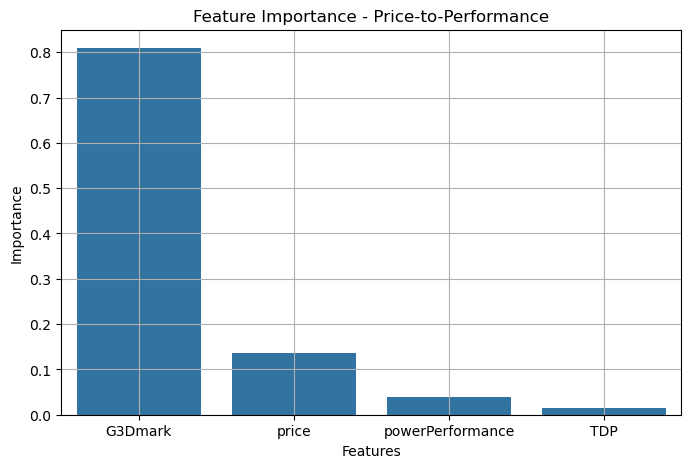

In [93]:
##Price to performance
import numpy as np  

price_perf_features = data[['price', 'G3Dmark', 'TDP', 'powerPerformance']]
price_perf_target = data['gpuValue']

X_train_perf, X_test_perf, y_train_perf, y_test_perf = train_test_split(
    price_perf_features, price_perf_target, test_size=0.2, random_state=42
)

scaler = RobustScaler()
X_train_perf_scaled = scaler.fit_transform(X_train_perf)
X_test_perf_scaled = scaler.transform(X_test_perf)

rf_regressor = RandomForestRegressor(random_state=42, n_estimators=100)
rf_regressor.fit(X_train_perf_scaled, y_train_perf)

y_pred_perf = rf_regressor.predict(X_test_perf_scaled)
rmse_perf = np.sqrt(mean_squared_error(y_test_perf, y_pred_perf))  
r2_perf = r2_score(y_test_perf, y_pred_perf)

print(f"Price-to-Performance RMSE: {rmse_perf:.2f}")
print(f"Price-to-Performance R2 Score: {r2_perf:.2f}")

price_perf_summary = pd.DataFrame({
    'Feature': ['price', 'G3DMark', 'TDP', 'powerPerformance'],
    'Importance': rf_regressor.feature_importances_
}).sort_values(by='Importance', ascending=False)

# Print the summary table
print("Price-to-Performance Feature Importance:")
print(price_perf_summary)

feature_importances = pd.DataFrame(
    rf_regressor.feature_importances_, index=['price', 'G3Dmark', 'TDP', 'powerPerformance'], columns=['Importance']
).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(8, 5))
sns.barplot(x=feature_importances.index, y=feature_importances['Importance'])
plt.title('Feature Importance - Price-to-Performance')
plt.xlabel('Features')
plt.ylabel('Importance')
plt.grid(True)
plt.show()


C:\Users\anura\anaconda3\Lib\site-packages\sklearn\metrics\_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


Energy Efficiency RMSE: 5.07
Energy Efficiency R2 Score: 0.96
Energy Efficiency Feature Importance:
    Feature  Importance
3   G3Dmark    0.822196
1       TDP    0.159119
0     price    0.011543
2  gpuValue    0.007143


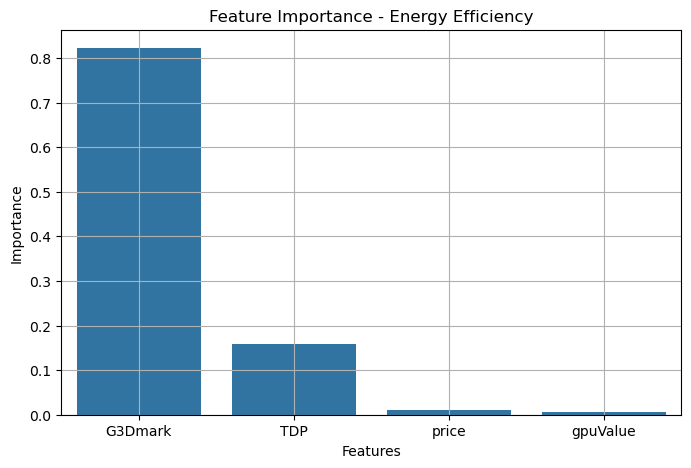

In [97]:
##Energy Efficiency
energy_features = data[['price', 'TDP', 'gpuValue', 'G3Dmark']]
energy_target = data['powerPerformance']

X_train_energy, X_test_energy, y_train_energy, y_test_energy = train_test_split(
    energy_features, energy_target, test_size=0.2, random_state=42
)

X_train_energy_scaled = scaler.fit_transform(X_train_energy)
X_test_energy_scaled = scaler.transform(X_test_energy)

rf_energy_regressor = RandomForestRegressor(random_state=42, n_estimators=100)
rf_energy_regressor.fit(X_train_energy_scaled, y_train_energy)

y_pred_energy = rf_energy_regressor.predict(X_test_energy_scaled)
rmse_energy = mean_squared_error(y_test_energy, y_pred_energy, squared=False)
r2_energy = r2_score(y_test_energy, y_pred_energy)

print(f"Energy Efficiency RMSE: {rmse_energy:.2f}")
print(f"Energy Efficiency R2 Score: {r2_energy:.2f}")

energy_efficiency_summary = pd.DataFrame({
    'Feature': ['price', 'TDP', 'gpuValue', 'G3Dmark'],
    'Importance': rf_energy_regressor.feature_importances_
}).sort_values(by='Importance', ascending=False)

print("Energy Efficiency Feature Importance:")
print(energy_efficiency_summary)

feature_importances_energy = pd.DataFrame(
    rf_energy_regressor.feature_importances_, index=['price', 'TDP', 'gpuValue','G3Dmark'], columns=['Importance']
).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(8, 5))
sns.barplot(x=feature_importances_energy.index, y=feature_importances_energy['Importance'])
plt.title('Feature Importance - Energy Efficiency')
plt.xlabel('Features')
plt.ylabel('Importance')
plt.grid(True)
plt.show()

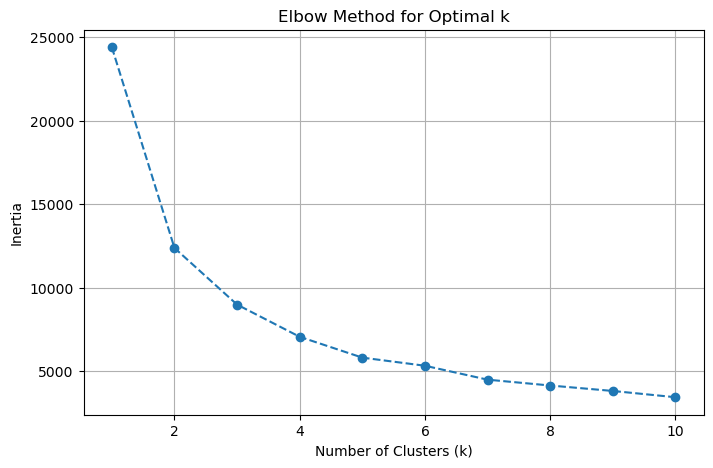


Market Segmentation - Cluster Characteristics:
                price       G3Dmark         TDP  powerPerformance   gpuValue
Cluster                                                                    
0         207.177807    569.481105   52.053694         12.405144   4.361413
1         907.219220  14354.991870  170.016260         99.159577  22.765821
2        3758.344222  12759.722222  202.766667         65.603481   5.788000
3         452.666288   4309.531017  133.064516         42.921251  16.541658


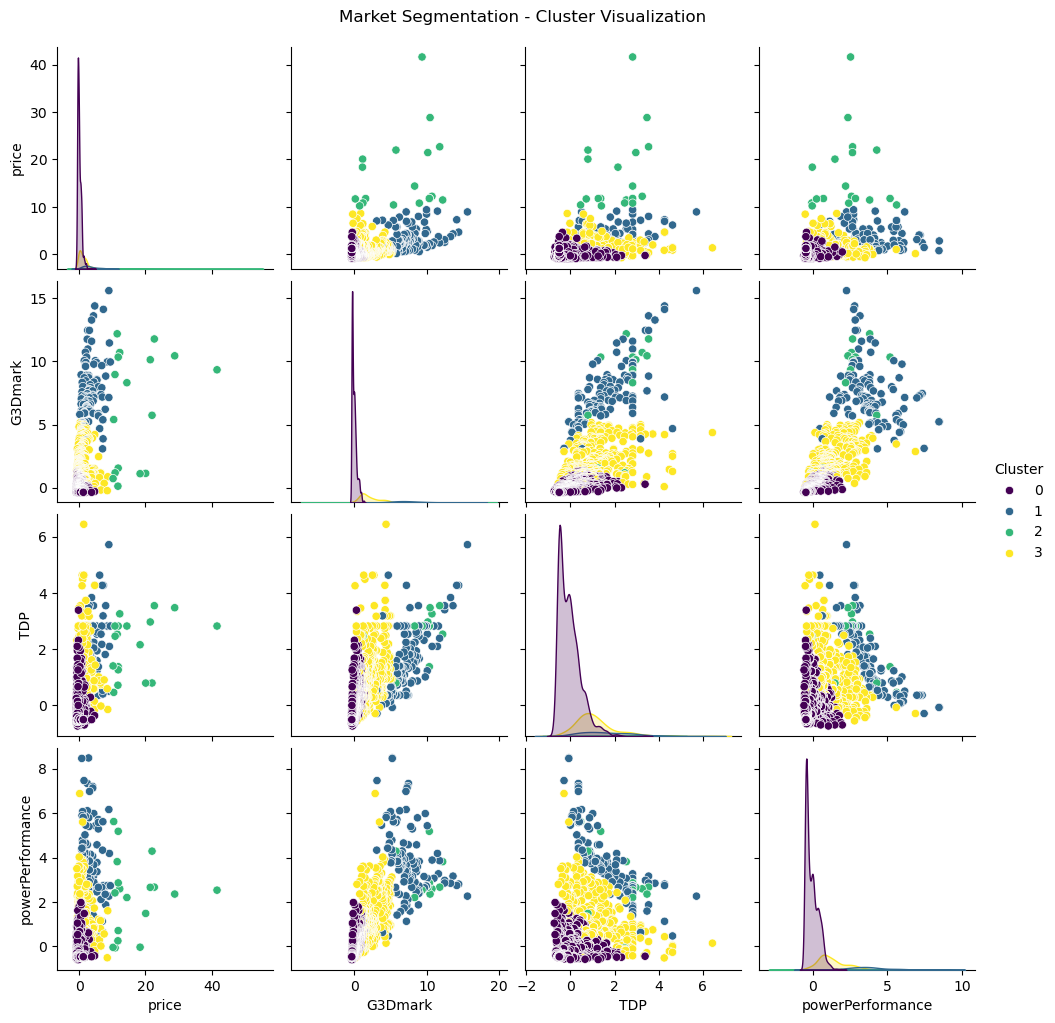

In [99]:
## Market Segmentation
features = data[['price', 'G3Dmark', 'TDP', 'powerPerformance']]
scaler = RobustScaler()
features_scaled = scaler.fit_transform(features)

inertia = []
k_values = range(1, 11)

for k in k_values:
    kmeans = KMeans(n_clusters=k, random_state=42, max_iter=500)
    kmeans.fit(features_scaled)
    inertia.append(kmeans.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(k_values, inertia, marker='o', linestyle='--')
plt.title('Elbow Method for Optimal k')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia')
plt.grid(True)
plt.show()

kmeans = KMeans(n_clusters=4, random_state=42, max_iter=500)
kmeans.fit(features_scaled)
data['Cluster'] = kmeans.labels_

cluster_analysis = data.groupby('Cluster')[['price', 'G3Dmark', 'TDP', 'powerPerformance', 'gpuValue']].mean()
print("\nMarket Segmentation - Cluster Characteristics:\n", cluster_analysis)

sns.pairplot(
    pd.DataFrame(features_scaled, columns=['price', 'G3Dmark', 'TDP', 'powerPerformance']).assign(Cluster=data['Cluster']),
    hue='Cluster', diag_kind='kde', palette='viridis'
)
plt.suptitle('Market Segmentation - Cluster Visualization', y=1.02)
plt.show()



In [100]:
### Save Final Results
# Save the dataset with all updates and predictions
data.to_csv('gpu_analysis_final_results.csv', index=False)
print("\nFinal results saved as 'gpu_analysis_final_results.csv'")

# Print the final analysis CSV file
print("\nFinal Analysis Dataset Preview:")
final_data = pd.read_csv('gpu_analysis_final_results.csv')
print(final_data.head())


Final results saved as 'gpu_analysis_final_results.csv'

Final Analysis Dataset Preview:
               gpuName  G3Dmark  G2Dmark    price  gpuValue    TDP  \
0  GeForce RTX 3090 Ti  29094.0     1117  2099.99     13.85  450.0   
1  GeForce RTX 3080 Ti  26887.0     1031  1199.99     22.41  350.0   
2     GeForce RTX 3090  26395.0      999  1749.99     15.08  350.0   
3    Radeon RX 6900 XT  25458.0     1102  1120.31     22.72  300.0   
4     GeForce RTX 3080  24853.0     1003   999.00     24.88  320.0   

   powerPerformance  testDate category  encoded_category  Cluster  
0             64.65      2022  Desktop                 4        1  
1             76.82      2021  Desktop                 0        1  
2             75.41      2020  Desktop                 0        1  
3             84.86      2020  Desktop                 0        1  
4             77.66      2020  Desktop                 0        1  


## **Conclusion**

This analysis provides NVIDIA with actionable insights to address key business challenges:

1. **Price-to-Performance Optimization**: By identifying factors like `G3DMark` and `price` as key drivers of customer value (`gpuValue`), NVIDIA can optimize its pricing strategies to enhance market appeal, especially in the budget GPU segment.
2. **Energy Efficiency Improvements**: Insights into `TDP` and `G3DMark` reveal opportunities to improve energy efficiency, making NVIDIA’s GPUs more attractive for data centers and portable devices.
3. **Market Segmentation**: Clustering GPUs into distinct categories (e.g., gaming, workstation) helps align product offerings with market demand and refine marketing strategies.

These findings strengthen NVIDIA’s ability to compete effectively and retain its leadership position in the GPU market.

---

## **Future Scope**

1. **Incorporating Competitor Data**: Expand the analysis by integrating datasets from competitors like AMD to benchmark NVIDIA’s performance and identify competitive gaps.
2. **Customer Behavior Analysis**: Use additional features like user feedback or application-specific benchmarks (e.g., gaming FPS) to better understand customer needs.
3. **Trend Analysis**: Analyze time-series data to track GPU performance trends and forecast future demands.
4. **Advanced Modeling**: Employ advanced machine learning models (e.g., Gradient Boosting, Neural Networks) for more accurate predictions of performance and efficiency metrics.
5. **Scalability**: Extend the analysis to include larger datasets and real-time insights for deployment in production systems.

These future directions will help NVIDIA stay ahead of evolving market demands and technological advancements.
